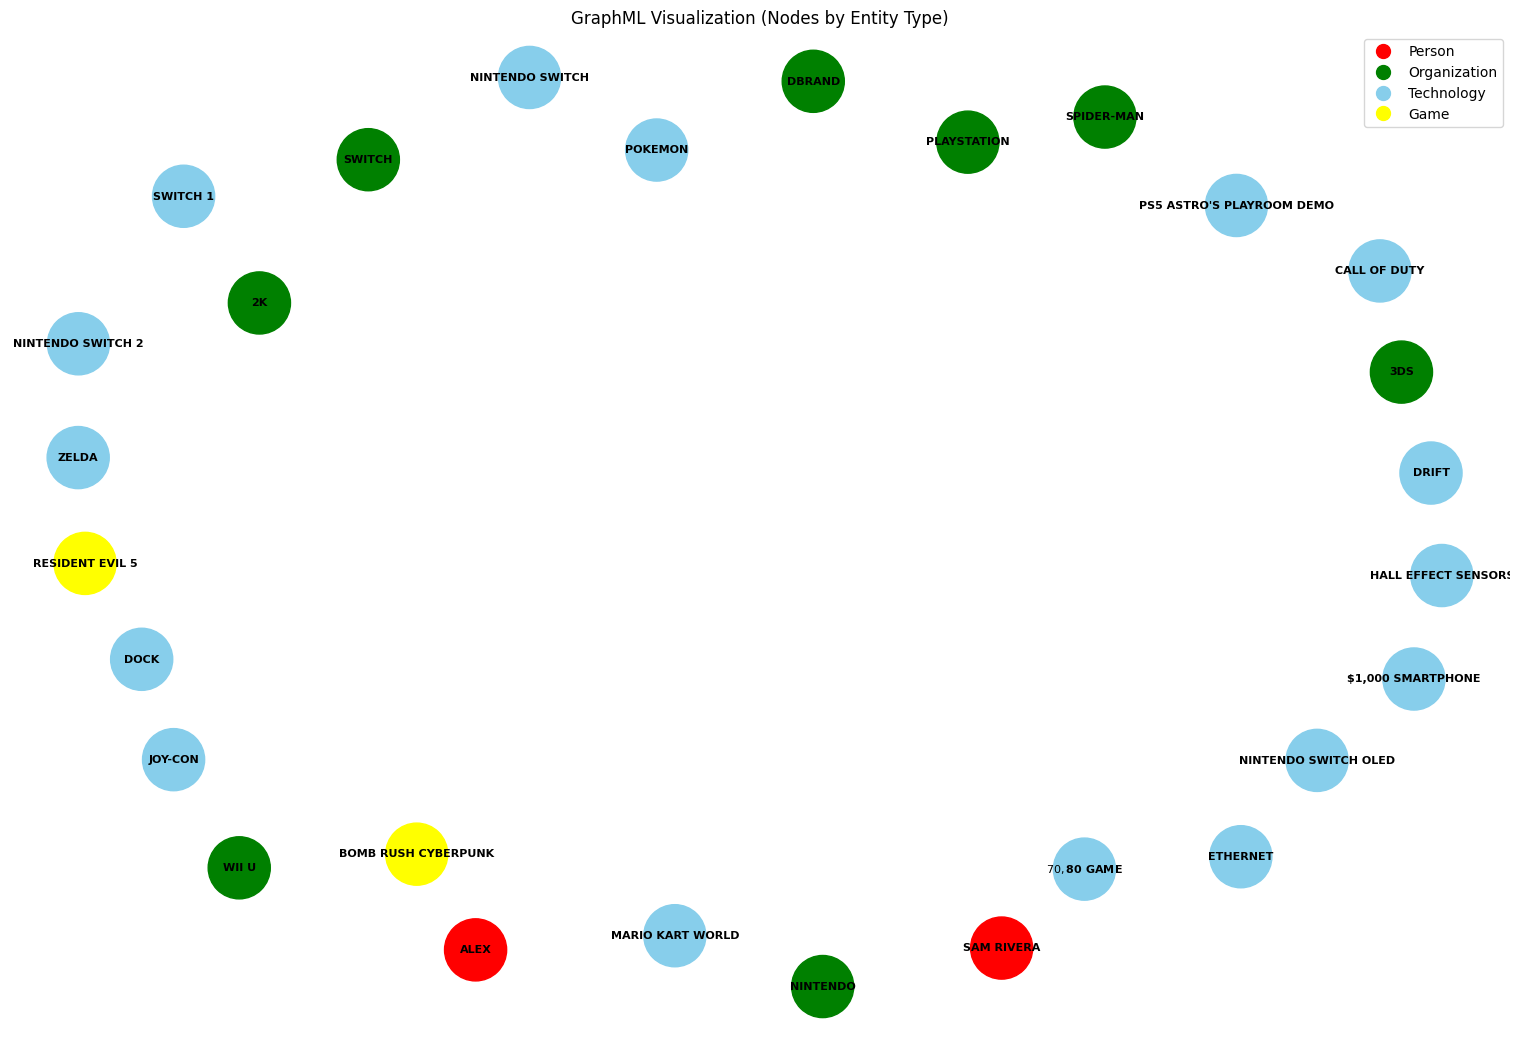

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Parse the GraphML file (assuming you saved your text as data.graphml)
# If using the string directly, we can use parse_xml, but here is the file load method:
# G = nx.read_graphml("data.graphml")

# Since I cannot load your local file, here is how to reconstruct it in Python:
G = nx.Graph()

# Adding nodes manually based on your XML to demonstrate the viz code
nodes = [
    ("ALEX", "PERSON"), ("SAM RIVERA", "PERSON"),
    ("NINTENDO", "ORGANIZATION"), ("DBRAND", "ORGANIZATION"), ("PLAYSTATION", "ORGANIZATION"),
    ("2K", "ORGANIZATION"), ("SPIDER-MAN", "ORGANIZATION"), ("WII U", "ORGANIZATION"),
    ("3DS", "ORGANIZATION"), ("SWITCH", "ORGANIZATION"),
    ("NINTENDO SWITCH 2", "TECHNOLOGY"), ("NINTENDO SWITCH", "TECHNOLOGY"),
    ("JOY-CON", "TECHNOLOGY"), ("NINTENDO SWITCH OLED", "TECHNOLOGY"),
    ("DOCK", "TECHNOLOGY"), ("ETHERNET", "TECHNOLOGY"), ("SWITCH 1", "TECHNOLOGY"),
    ("$1,000 SMARTPHONE", "TECHNOLOGY"), ("$70, $80 GAME", "TECHNOLOGY"),
    ("PS5 ASTRO'S PLAYROOM DEMO", "TECHNOLOGY"), ("HALL EFFECT SENSORS", "TECHNOLOGY"),
    ("DRIFT", "TECHNOLOGY"), ("MARIO KART WORLD", "TECHNOLOGY"),
    ("CALL OF DUTY", "TECHNOLOGY"), ("ZELDA", "TECHNOLOGY"), ("POKEMON", "TECHNOLOGY"),
    ("RESIDENT EVIL 5", "GAME"), ("BOMB RUSH CYBERPUNK", "GAME")
]

for name, entity_type in nodes:
    G.add_node(name, entity_type=entity_type)

# 2. Define Colors
color_map = []
for node in G:
    etype = G.nodes[node]['entity_type']
    if etype == "PERSON": color_map.append('red')
    elif etype == "ORGANIZATION": color_map.append('green')
    elif etype == "TECHNOLOGY": color_map.append('skyblue')
    elif etype == "GAME": color_map.append('yellow')
    else: color_map.append('grey')

# 3. Draw
plt.figure(figsize=(15, 10))
pos = nx.spring_layout(G, k=0.5, iterations=50) # Spread nodes out
nx.draw(G, pos, node_color=color_map, with_labels=True, 
        node_size=2000, font_size=8, font_weight='bold', edge_color="gray")

# Add Legend
plt.plot([],[], marker="o", ms=10, ls="", mec=None, color="red", label="Person")
plt.plot([],[], marker="o", ms=10, ls="", mec=None, color="green", label="Organization")
plt.plot([],[], marker="o", ms=10, ls="", mec=None, color="skyblue", label="Technology")
plt.plot([],[], marker="o", ms=10, ls="", mec=None, color="yellow", label="Game")
plt.legend()

plt.title("GraphML Visualization (Nodes by Entity Type)")
plt.show()

In [3]:
import networkx as nx
from pyvis.network import Network
import os

def visualize_interactive(file_path, output_file="graph_visualization.html"):
    """
    Reads a GraphML file and generates an interactive HTML visualization.
    """
    if not os.path.exists(file_path):
        print(f"Error: File not found at {file_path}")
        return

    # 1. Load the Graph
    print(f"Loading {file_path}...")
    try:
        G = nx.read_graphml(file_path)
    except Exception as e:
        print(f"Error parsing GraphML: {e}")
        return

    print(f"Nodes: {len(G.nodes())} | Edges: {len(G.edges())}")

    # 2. Initialize PyVis Network
    # height/width: size of the window
    # notebook=False: generates a standalone HTML file
    net = Network(height="750px", width="100%", bgcolor="#222222", font_color="white", select_menu=True)
    
    # 3. Smart Coloring (Optional)
    # If your nodes have 'entity_type' (like in your previous file), we map it to 'group' for auto-coloring
    for node, data in G.nodes(data=True):
        if 'entity_type' in data:
            data['group'] = data['entity_type'] # PyVis uses 'group' to assign colors automatically
            # Clean up string quotes if necessary (e.g., '"PERSON"' -> 'PERSON')
            data['label'] = str(node).replace('"', '') 
            data['title'] = data.get('description', str(node)) # Tooltip on hover

    # 4. Convert NetworkX graph to PyVis
    net.from_nx(G)

    # 5. Physics Settings (Helps spread out disconnected nodes)
    net.toggle_physics(True)
    net.show_buttons(filter_=['physics']) # Adds a control panel to the UI

    # 6. Save and Show
    try:
        net.show(output_file, notebook=False)
        print(f"Success! Visualization saved to: {os.path.abspath(output_file)}")
    except Exception as e:
        print(f"Error saving file: {e}")

# --- USAGE ---
# Replace with your path
path = "your_file.graphml" 
visualize_interactive(path)

Error: File not found at your_file.graphml
